In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [7]:
df=pd.read_csv("/content/Salary Data.csv")

In [18]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [10]:
print("Null values before dropping:")
print(df.isnull().sum())

Null values before dropping:
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [11]:
df.dropna(inplace=True)
print("\nNull values after dropping:")
print(df.isnull().sum())


Null values after dropping:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [12]:
print("\nDataFrame info after dropping nulls:")
df.info()


DataFrame info after dropping nulls:
<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 20.4+ KB


In [13]:
print("Null values before imputation:")
print(df.isnull().sum())

Null values before imputation:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [14]:
# Impute 'Age', 'Years of Experience', and 'Salary' with their mean
for col in ['Age', 'Years of Experience', 'Salary']:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

# Impute 'Gender', 'Job Title', and 'Education Level' with their mode
for col in ['Gender', 'Job Title', 'Education Level']:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nNull values after imputation:")
print(df.isnull().sum())


Null values after imputation:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [15]:
print("\nDataFrame info after imputation:")
df.info()


DataFrame info after imputation:
<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 20.4+ KB


In [16]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# List of categorical columns to encode
categorical_cols = ['Gender', 'Education Level', 'Job Title']

# Apply Label Encoding to each categorical column
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("DataFrame after Label Encoding:")
display(df.head())

DataFrame after Label Encoding:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


In [17]:
print("\nDataFrame info after Label Encoding:")
df.info()


DataFrame info after Label Encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    int64  
 2   Education Level      373 non-null    int64  
 3   Job Title            373 non-null    int64  
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 20.4 KB


In [19]:
# Separate input (features) and output (target) columns
X = df.drop('Salary', axis=1)
y = df['Salary']

print("Input features (X):")
display(X.head())

print("\nOutput target (y):")
display(y.head())

Input features (X):


,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,1,0,159,5.0
1,28.0,0,1,17,3.0
2,45.0,1,2,130,15.0
3,36.0,0,0,101,7.0
4,52.0,1,1,22,20.0



Output target (y):


,Salary
0,90000.0
1,65000.0
2,150000.0
3,60000.0
4,200000.0


In [21]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (298, 5)
Shape of X_test: (75, 5)
Shape of y_train: (298,)
Shape of y_test: (75,)


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# Initialize the models
models = {
    "Linear Regression": LinearRegression(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# Train each model in a loop
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")


Training Linear Regression...
Linear Regression trained successfully.
Training K-Nearest Neighbors...
K-Nearest Neighbors trained successfully.
Training Decision Tree...
Decision Tree trained successfully.
Training Support Vector Regressor...
Support Vector Regressor trained successfully.
Training Random Forest...
Random Forest trained successfully.


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate each model
results = {}
for name, model in models.items():
    print(f"\nEvaluating {name}...")
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse) # Calculate RMSE
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")

# Display all results in a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
print("\n--- Model Evaluation Results ---")
display(results_df.sort_values(by='R2', ascending=False))



Evaluating Linear Regression...
  Mean Absolute Error (MAE): 10928.92
  Mean Squared Error (MSE): 249075656.43
  Root Mean Squared Error (RMSE): 15782.13
  R-squared (R2): 0.90

Evaluating K-Nearest Neighbors...
  Mean Absolute Error (MAE): 11892.40
  Mean Squared Error (MSE): 325434465.33
  Root Mean Squared Error (RMSE): 18039.80
  R-squared (R2): 0.86

Evaluating Decision Tree...
  Mean Absolute Error (MAE): 10466.67
  Mean Squared Error (MSE): 267666666.67
  Root Mean Squared Error (RMSE): 16360.52
  R-squared (R2): 0.89

Evaluating Support Vector Regressor...
  Mean Absolute Error (MAE): 40525.12
  Mean Squared Error (MSE): 2453008012.86
  Root Mean Squared Error (RMSE): 49527.85
  R-squared (R2): -0.02

Evaluating Random Forest...
  Mean Absolute Error (MAE): 8524.79
  Mean Squared Error (MSE): 143564355.42
  Root Mean Squared Error (RMSE): 11981.83
  R-squared (R2): 0.94

--- Model Evaluation Results ---


,MAE,MSE,RMSE,R2
Random Forest,8524.791000,1.435644e+08,11981.834393,0.940121
Linear Regression,10928.921486,2.490757e+08,15782.130922,0.896114
Decision Tree,10466.666667,2.676667e+08,16360.521589,0.888360
K-Nearest Neighbors,11892.400000,3.254345e+08,18039.802253,0.864266
Support Vector Regressor,40525.116955,2.453008e+09,49527.850881,-0.023117


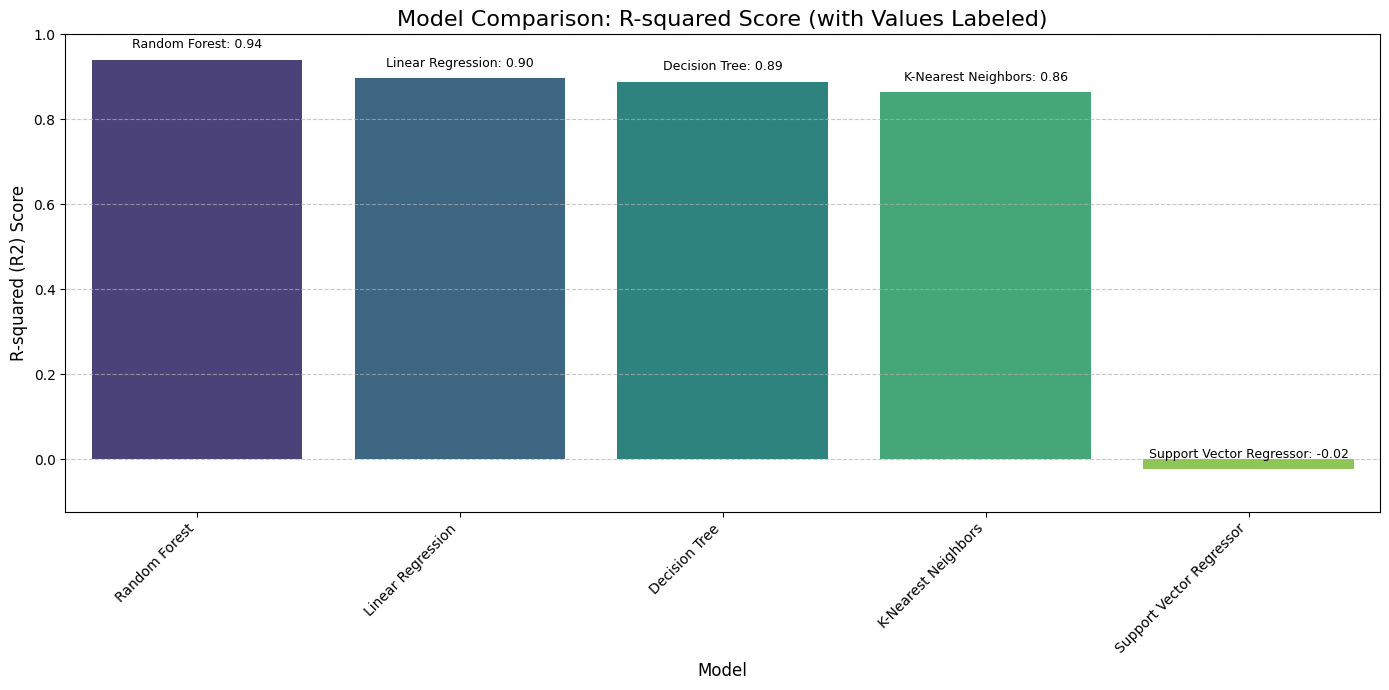

In [26]:
plt.figure(figsize=(14, 7))
sorted_results_df = results_df.sort_values(by='R2', ascending=False)
sns.barplot(x=sorted_results_df.index, y='R2', hue=sorted_results_df.index, data=sorted_results_df, palette='viridis', legend=False)
plt.title('Model Comparison: R-squared Score (with Values Labeled)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('R-squared (R2) Score', fontsize=12)
plt.ylim(min(sorted_results_df['R2'].min() - 0.1, 0), 1) # Ensure y-axis starts from 0 or slightly below min R2
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text annotations on top of each bar
for index, row in sorted_results_df.iterrows():
    plt.text(index, row['R2'] + 0.02, f'{index}: {row["R2"]:.2f}', color='black', ha="center", va="bottom", fontsize=9, rotation=0)

plt.tight_layout()
plt.show()


### Understanding Model Accuracy and Evaluation Metrics

The evaluation results provide a comprehensive view of how each model performed. Here's a breakdown:

*   **R-squared (R2) Score**: This metric represents the proportion of the variance in the dependent variable (Salary) that can be predicted from the independent variables (features). An R2 score of 1 indicates that the model explains all the variability of the response data around its mean, while 0 indicates no linear relationship. A negative R2 score, as seen with the Support Vector Regressor, means the model performs worse than simply predicting the mean of the target variable.
    *   **Higher R2 is better.**

*   **Mean Absolute Error (MAE)**: This is the average of the absolute differences between predictions and actual values. It measures the average magnitude of the errors in a set of predictions, without considering their direction. Since it uses absolute values, it doesn't penalize large errors as severely as MSE or RMSE.
    *   **Lower MAE is better.**

*   **Mean Squared Error (MSE)**: This is the average of the squared differences between predictions and actual values. By squaring the errors, MSE penalizes larger errors more heavily than smaller ones. This makes it sensitive to outliers.
    *   **Lower MSE is better.**

*   **Root Mean Squared Error (RMSE)**: This is the square root of the MSE. RMSE is often preferred over MSE because it is in the same units as the target variable (Salary), making it more interpretable. Like MSE, it gives higher weight to larger errors.
    *   **Lower RMSE is better.**


### Model Accuracy Analysis

From the evaluation results and the R2 plot, we can clearly see the performance of each model:

*   **Most Accurate Model: Random Forest Regressor**
    *   **R2 Score: 0.94** (Highest)
    *   **MAE: 8524.79** (Lowest)
    *   **MSE: 1.44e+08** (Lowest)
    *   **RMSE: 11981.83** (Lowest)
    
The Random Forest Regressor significantly outperforms all other models. Its high R2 score indicates that it explains 94% of the variance in salary, meaning it captures most of the underlying patterns in the data. The low MAE, MSE, and RMSE scores confirm that its predictions are, on average, closest to the actual salaries.

*   **Least Accurate Model: Support Vector Regressor**
    *   **R2 Score: -0.02** (Lowest, and negative)
    *   **MAE: 40525.12** (Highest)
    *   **MSE: 2.45e+09** (Highest)
    *   **RMSE: 49527.85** (Highest)
    
The Support Vector Regressor performed very poorly, evidenced by its negative R2 score. This suggests that simply predicting the average salary would be more accurate than using this SVR model without any further tuning or preprocessing. SVR models are often highly sensitive to feature scaling and hyperparameter choices, which were not optimized in this basic implementation.


*   **Other Models (Linear Regression, Decision Tree, K-Nearest Neighbors)**: These models show reasonable performance, with R2 scores ranging from 0.86 to 0.90. They are much better than the SVR but not as robust as the Random Forest Regressor.


In summary, the **Random Forest Regressor** is the most accurate model among those tested for predicting salary, demonstrating superior performance across all key metrics.